## Traveling Wave L2Norm Convergence

The goal is to show that as the dimensionality increases, the L2Norm goes to 0.

In [1]:
using LinearAlgebra, Polynomials, Plots
using Revise, DelimitedFiles, BenchmarkTools
using CloudAtlas, ChannelflowWrapper
using Printf
using CSV
using DataFrames

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

macro suppress(ex)
    quote
        # Generate a unique name for the old stdout to avoid variable collision
        local old_stdout = stdout
        redirect_stdout(devnull)
        try
            # We use esc(ex) to run the expression in the caller's scope
            $(esc(ex))
        finally
            redirect_stdout(old_stdout)
        end
    end
end

sx, sy, sz, tx, tz = halfbox_symmetries()

cd("tw_convergence/")
pwd()


"/home/ebenq/Dev/julia/CloudAtlas.jl/notebooks/tw_convergence"

This is the goal:

- projerr   = ||uproj-u||/||u||
- solnorm   = ||uode||
- solnerr   = ||uode-udns||/||udns||
- ||udns|| = 0.25630308

```
#J K L Nd    projerr    solnerr   solnrm    success ODE eqb?
1 1 3  17    0.135913   0.397485  0.32665   # true
1 2 3  27    0.078738   0.242049  0.285781  # true
1 3 5  59    0.0373368  0.168478  0.2222952 # true
2 4 7  169   0.01172    0.03643   0.249322  # true
3 5 9  367   0.004294   0.005830  0.256522  # true
4 6 11 673   0.001651   0.00224   0.2564914 # true
5 7 13 1115  0.0006396  0.0007561 0.256302  # true




#1 1 1  8     0.200295   10         0         # false (laminar)
#1 2 1  12    0.176148   10         0         # false (laminar)
#1 1 1  8     0.200295
#1 2 2  19    0.149869   0.289964  0.243966  
#1 2 3  27    0.078738
#1 2 5  42    0.05871    0.161642  0.2253431 # true
#2 3 3  62    0.06054
#2 3 5  97    0.024312   0.12233   0.253269  # true
#2 4 5  124   0.023108
#2 4 7  169   0.01172
#3 5 7  290   0.008920
#3 5 9  367   0.004294
#4 6 9  556   0.003624
#4 6 11 673   0.001651
#5 7 11 950   0.001479
#5 7 13 1115  0.0006396
```

In [2]:
# Parameters
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
discretizations = [(1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 3), (1, 3, 5), (2, 4, 7), (3, 4, 7), (4, 4, 7), (3, 5, 9), (4, 5, 9)]
# discretizations = [(1, 1, 3), (1, 2, 3), (1, 3, 5), (2, 4, 7)]
# discretizations = [(1, 1, 3), (1, 2, 3)]
H = [(sx*sy)*(tx*tz)]               # Generators of the symmetric subspace of TW1
normalize = true                  # Normalize the basis set or not?

true

In [3]:
"""
Analyze convergence across multiple discretizations
"""
function analyze_convergence(discretizations, udns_file; 
                            α=1.0, γ=2.0, H=symmetry, Re=200.0, cx0 = 0.0, cz0 = 0.0)
    
    results = []
    
    # Get DNS field norm once (denominator for all errors)
    udns_norm = @suppress L2norm(udns_file)
    println("||u_DNS|| = $udns_norm")
    
    for jkl in discretizations
        println("\n" * "="^70)
        println("Analyzing J,K,L = $jkl")
        println("="^70)
        
        J, K, L = jkl
        
        # 1. Construct ODE model
        model = TWModel(α, γ, J, K, L, H; normalize=false)
        m = length(model)
        println("Model dimension m = $m")

        filename_base = "jkl-$(J)-$(K)-$(L)"
        # Project DNS field onto basis (get coefficients x_proj)
        xproj = @suppress field2coeff(model.ijkl, udns_file, "x-proj-$(filename_base).asc")
        
        projerr = @suppress begin
            # Reconstruct projected field and calculate projection error
            coeff2field(xproj, model.ijkl, udns_file, "u-proj-$(filename_base).nc")
            # subtract the field 
            addfields("u_projerr-$(filename_base).nc", 1.0 => "u-proj-$(filename_base).nc", -1.0 => udns_file)
            # calculate the projection error
            L2norm("u_projerr-$(filename_base).nc") / udns_norm
        end
        println("Projection error = $(projerr)")
        
        
        # --- Find ODE equilibrium starting from projection --- 
        println("Solving for ODE equilibrium...")
        ξ_guess = vcat(xproj, cx0, cz0) 
        
        # Solve g(ξ, R) = 0 where ξ = [x; cx; cz]
        f_Re(ξ) = model.g(ξ, Re)
        Df_Re(ξ) = model.Dg(ξ, Re)

        ξ_star, converged = @suppress hookstepsolve(f_Re, Df_Re, ξ_guess, SearchParams(verbosity=0, Nnewton=30, Nhook=8))
        
        if !converged
            println("Warning: ODE solve did not converge for J,K,L=$jkl")
        end
        
        x_ode = ξ_star[1:m]
        cx_ode = ξ_star[m+1]
        cz_ode = ξ_star[m+2]
        
        println("ODE solution: cx = $cx_ode, cz = $cz_ode")
        
        # 5. Reconstruct ODE equilibrium field and calculate equilibrium error
        eqerr = @suppress begin
            coeff2field(x_ode, model.ijkl, udns_file, "u-ode-$(filename_base).nc")
            addfields("u-eqb-err-$(filename_base).nc", 1.0 => "u-ode-$(filename_base).nc", -1.0 => udns_file)
            L2norm("u-eqb-err-$(filename_base).nc") / udns_norm
        end
        println("Equilibrium error = $eqerr")
        
        push!(results, (J=J, K=K, L=L, m=m, 
                       projerr=projerr, eqerr=eqerr,
                       cx=cx_ode, cz=cz_ode, converged=converged))
    end
    
    return results
end

analyze_convergence

In [4]:
results = analyze_convergence(discretizations, "./TW1-2pi1piRe200-40x49x40.nc"; α=α, γ=γ, H=H, Re=200.0, cx0 = 0.000, cz0 = 0.009)
# Save directly
CSV.write("tw1_convergence_results.csv", results)

||u_DNS|| = 0.27925901954995114

Analyzing J,K,L = (1, 1, 1)
J,K,L,m == 1,1,1,15
(2J+1)(2K+1)(2L+1) + 1 == 28
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = false, keep_cz = true
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Model dimension m = 15
Projection error = 0.2814386254284499
Solving for ODE equilibrium...
ODE solution: cx = 0.0, cz = 0.00018215289516086523
Equilibrium error = 1.0

Analyzing J,K,L = (1, 1, 2)
J,K,L,m == 1,1,2,24
(2J+1)(2K+1)(2L+1) + 1 == 46
Making matrices B, A1, A2, Cx, Cz...
Phase constraints: keep_cx = false, keep_cz = true
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 
Model dimension m = 24
Projection error = 0.19326008223990304
Solving for ODE equilibrium...
ODE solution: cx = 0.0, cz = -0.009882745746495277
Equilibrium error = 0.5134972721578682

Analyzing J,K,L = (1, 1, 3)
J,K,L,m == 1,1,3,33
(2J+1)(2K+1)(2L+1) + 1 == 64
Making matrices B, A1, A2, Cx, Cz...
Phase c

"tw1_convergence_results.csv"

In [5]:
df = DataFrame(results)

show(df, allcols=true)

10×9 DataFrame
 Row │ J      K      L      m      projerr     eqerr      cx       cz            converged 
     │ Int64  Int64  Int64  Int64  Float64     Float64    Float64  Float64       Bool      
─────┼─────────────────────────────────────────────────────────────────────────────────────
   1 │     1      1      1     15  0.281439    1.0            0.0   0.000182153       true
   2 │     1      1      2     24  0.19326     0.513497       0.0  -0.00988275       false
   3 │     1      1      3     33  0.159674    0.370899       0.0   3.93079e-14       true
   4 │     1      2      3     53  0.105881    0.282476       0.0   3.65333e-9        true
   5 │     1      3      5    117  0.0639724   0.181812       0.0  -0.0206125         true
   6 │     2      4      7    338  0.0233042   0.209701       0.0  -0.0291709        false
   7 │     3      4      7    473  0.0153548   0.173914       0.0  -0.0260523        false
   8 │     4      4      7    608  0.0142394   0.137758       0.0  -0.02

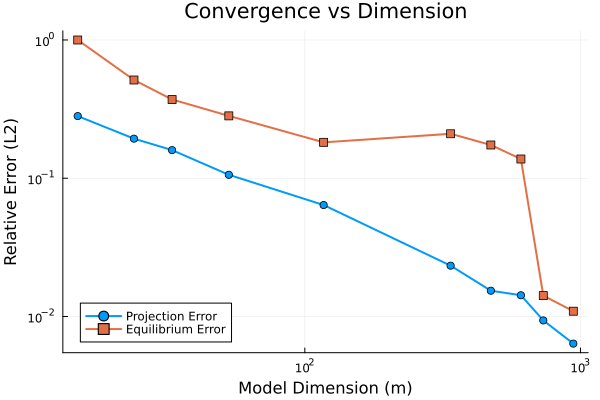

In [6]:
# Create the plot
p = plot(df.m, df.projerr, 
    label  = "Projection Error",
    xlabel = "Model Dimension (m)",
    ylabel = "Relative Error (L2)",
    title  = "Convergence vs Dimension",
    marker = :circle,
    linewidth = 2,
    yaxis  = :log10,  # Log scale for errors
    xaxis  = :log10,  # Often useful for dimension too
    legend = :bottomleft
)

# Add the equilibrium error
plot!(p, df.m, df.eqerr, 
    label  = "Equilibrium Error",
    marker = :square,
    linewidth = 2
)

# Save it
savefig(p, "convergence_plot.png")
display(p)